<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/binarystar_A0620_00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Binary star system A0620-008**

The A0620−00 system is a well-known X-ray binary system that consists of a black hole and a low-mass companion star. Analyzing such a system involves understanding its light curve, orbital parameters, and sometimes its X-ray emission.

https://en.m.wikipedia.org/wiki/A0620-00

In [1]:
!pip install astroquery astropy lightkurve -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.4/270.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.9/912.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 20.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.6.1 requires fsspec==2024.6.1, but you have fsspec 2024.9

Coordinates of A0620-00: RA = 06 22 44.5423, Dec = -00 20 44.290


/usr/local/lib/python3.10/dist-packages/lightkurve/search.py:424: LightkurveWarning: Warning: 5 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
<ipython-input-4-0da580562ff0>:29: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lc_file.PDCSAP_FLUX


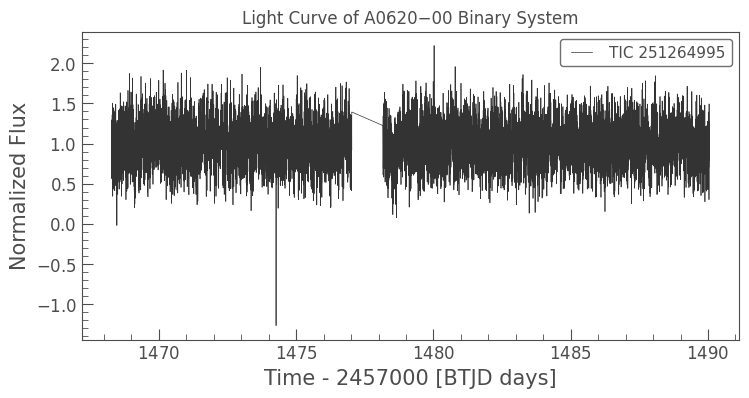

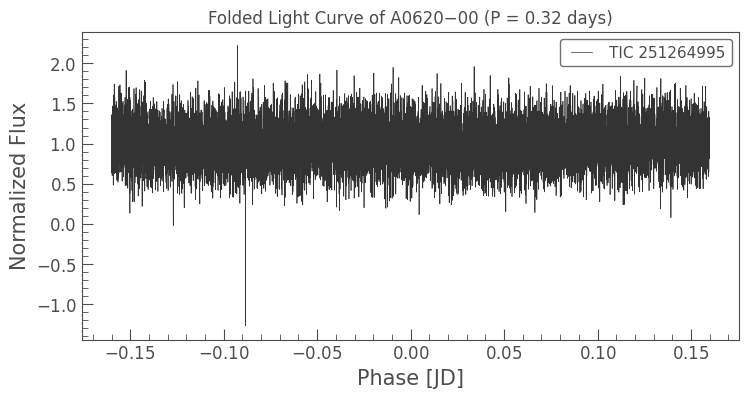

In [4]:
import lightkurve as lk
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

# Query SIMBAD for the A0620−00 system's position (RA, Dec)
custom_simbad = Simbad()
custom_simbad.add_votable_fields('coordinates')

# Search for A0620-00 in SIMBAD
result_table = custom_simbad.query_object("V616 Mon")

# Extract coordinates from the result
ra = result_table['RA'][0]
dec = result_table['DEC'][0]
print(f"Coordinates of A0620-00: RA = {ra}, Dec = {dec}")

# Convert RA and DEC into SkyCoord object
coords = SkyCoord(f"{ra} {dec}", unit=(u.hourangle, u.deg))

# Now, let's download the light curve for this object using the coordinates
search_result = lk.search_lightcurve(coords, mission="TESS")

# If there are multiple data sets, select one
lc_file = search_result.download()

# Load the light curve data
lc = lc_file.PDCSAP_FLUX

# Remove NaN values and normalize the flux
lc = lc.remove_nans().normalize()

# Plot the light curve
lc.plot()
plt.title('Light Curve of A0620−00 Binary System')
plt.show()

# Fold the light curve by period to analyze the binary's orbital features
period = 0.32  # Approximate orbital period in days (adjust as needed)
folded_lc = lc.fold(period=period)

# Plot the folded light curve
folded_lc.plot()
plt.title(f'Folded Light Curve of A0620−00 (P = {period} days)')
plt.show()

* Simbad Query: This part queries the SIMBAD database to get the exact coordinates of the A0620−00 system.
* Lightkurve Search: The lightkurve package is used to search for and download photometric data from missions like Kepler or TESS. The SkyCoord object is passed to search for light curves near the coordinates of A0620−00.
* Light Curve Normalization and Plotting: The light curve is cleaned of NaN values, normalized, and then plotted. This shows the brightness of the binary system over time.
* Folding the Light Curve: Since the A0620−00 system is a binary, it has a periodic signal related to its orbit. We fold the light curve by its orbital period to highlight any repeating features, such as eclipses or modulations in the light curve due to the interaction between the black hole and the companion star.
* Orbital Period: The period of A0620−00 is approximately 0.32 days (this value can be refined based on more precise data).
* Variability: By folding the light curve, you can study periodic changes in brightness, which are often caused by the orbital motion of the companion star or accretion events.

In [ ]:
# Analyze features such as eclipses, outbursts, or variability

**Spectral Analysis**

For spectral analysis of A0620−00, we can use spectra from various databases, like Simbad, VizieR, or X-ray data archives like HEASARC (if you're looking for X-ray spectra). For optical or near-infrared spectra, you may look for archives such as ESO, SDSS, or Hubble data.

Obtain and analyze spectra of A0620−00, focusing on the black hole accretion disk or the companion star.

In [5]:
from astroquery.vizier import Vizier
import astropy.units as u

# Querying VizieR for spectral data of A0620-00 using its catalog name
vizier = Vizier(columns=["RAJ2000", "DEJ2000", "spType"])
result = vizier.query_object("V616 Mon", catalog="II/246")

# Display the results
print(result)

TableList with 1 tables:
	'0:II/246/out' with 2 column(s) and 50 row(s) 


This will search for spectral data of A0620−00 in the VizieR database. The catalog "II/246" is just an example; you may need to search different catalogs for spectral data

**X-ray Spectral Analysis**

Analyzing X-ray spectra to study the black hole accretion disk, use HEASARC's X-ray data

In [7]:
from astroquery.heasarc import Heasarc
from astropy.coordinates import SkyCoord
import astropy.units as u

heasarc = Heasarc()

# Coordinates of A0620−00 from earlier
coords = SkyCoord(ra=95.68559292*u.deg, dec=-0.34563611*u.deg)

# Query HEASARC for X-ray observations of A0620−00
result = heasarc.query_region(coords, mission="swiftmastr", radius="0.1 deg")

# Print the result to see available data
print(result)

                                      NAME                                       ...
                                                                                 ...
-------------------------------------------------------------------------------- ...
A0620-00                                                                         ...
A0620-00                                                                         ...
A0620-00                                                                         ...
A0620-00                                                                         ...
A0620-00                                                                         ...
A0620-00                                                                         ...
A0620-00                                                                         ...
